# What Drives GitHub Repository Success? A Data-Driven Analysis of Open-Source Projects

## Imports and configurations

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
import os

parent_dir = os.path.dirname(os.path.abspath(''))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

## Dataset import

In [ ]:
df = pd.read_csv("../data/raw/GitHub_Top_500_Repos_By_Stars.csv")
df.head()

,name,full_name,description,stars,forks,watchers,language,created_at,updated_at,open_issues,license,topics,size_kb,is_fork,archived,homepage
0,build-your-own-x,codecrafters-io/build-your-own-x,Master programming by recreating your favorite...,487558,45879,487558,Markdown,2018-05-09T12:03:18Z,2026-04-08T22:08:47Z,461,NaN,"awesome-list, free, programming, tutorial-code...",1201,False,False,https://codecrafters.io
1,awesome,sindresorhus/awesome,😎 Awesome lists about all kinds of interesting...,453265,34050,453265,NaN,2014-07-11T13:42:37Z,2026-04-08T22:13:57Z,59,CC0-1.0,"awesome, awesome-list, lists, resources, unicorns",1535,False,False,NaN
2,freeCodeCamp,freeCodeCamp/freeCodeCamp,freeCodeCamp.org's open-source codebase and cu...,442227,44188,442227,TypeScript,2014-12-24T17:49:19Z,2026-04-08T22:09:14Z,200,BSD-3-Clause,"careers, certification, community, curriculum,...",559008,False,False,https://contribute.freecodecamp.org
3,public-apis,public-apis/public-apis,A collective list of free APIs,420261,45730,420261,Python,2016-03-20T23:49:42Z,2026-04-08T22:11:51Z,1216,MIT,"api, apis, dataset, development, free, list, l...",4962,False,False,https://APILayer.com/?utm_source=Github&utm_me...
4,free-programming-books,EbookFoundation/free-programming-books,:books: Freely available programming books,385203,66095,385203,Python,2013-10-11T06:50:37Z,2026-04-08T22:10:37Z,80,CC-BY-4.0,"books, education, hacktoberfest, list, resource",21200,False,False,https://ebookfoundation.github.io/free-program...


## Basic info check

In [ ]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   name         500 non-null    str  
 1   full_name    500 non-null    str  
 2   description  498 non-null    str  
 3   stars        500 non-null    int64
 4   forks        500 non-null    int64
 5   watchers     500 non-null    int64
 6   language     442 non-null    str  
 7   created_at   500 non-null    str  
 8   updated_at   500 non-null    str  
 9   open_issues  500 non-null    int64
 10  license      461 non-null    str  
 11  topics       428 non-null    str  
 12  size_kb      500 non-null    int64
 13  is_fork      500 non-null    bool 
 14  archived     500 non-null    bool 
 15  homepage     369 non-null    str  
dtypes: bool(2), int64(5), str(9)
memory usage: 55.8 KB


,stars,forks,watchers,open_issues,size_kb
count,500.000000,500.00000,500.000000,500.000000,5.000000e+02
mean,83430.586000,13515.91600,83430.586000,1062.450000,4.720237e+05
std,58671.168857,14249.69869,58671.168857,2709.321904,2.478883e+06
min,44205.000000,1237.00000,44205.000000,0.000000,5.000000e+00
25%,51509.000000,5440.00000,51509.000000,66.000000,1.052075e+04
50%,64183.000000,9020.00000,64183.000000,283.000000,6.378200e+04
75%,88458.000000,15189.50000,88458.000000,838.000000,2.642518e+05
max,487558.000000,105876.00000,487558.000000,33138.000000,4.354393e+07


## Missing values

In [ ]:
df.isnull().sum()

name             0
full_name        0
description      2
stars            0
forks            0
watchers         0
language        58
created_at       0
updated_at       0
open_issues      0
license         39
topics          72
size_kb          0
is_fork          0
archived         0
homepage       131
dtype: int64

## Basic cleaning

In [ ]:
from src.clean_data import clean_data
df = clean_data(df)

Dropping duplicates, removing missing stars and forks, filling missing languages

## Stars distribution

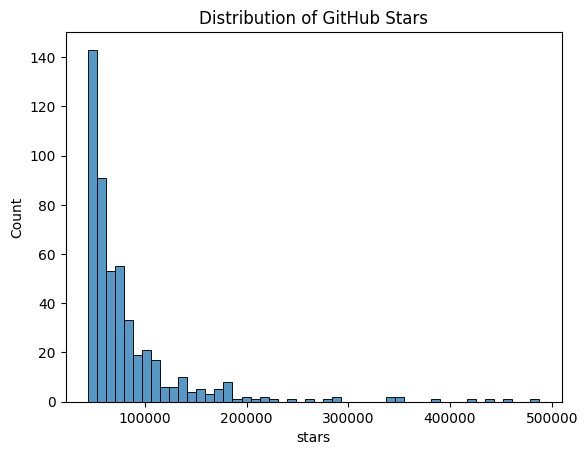

In [ ]:
plt.figure()
sns.histplot(df["stars"], bins=50)
plt.title("Distribution of GitHub Stars")
plt.show()

High skewness, showing stars are not evenly distributed among repositories

## Top languages

Text(0.5, 1.0, 'Top Programming Languages in Repos')

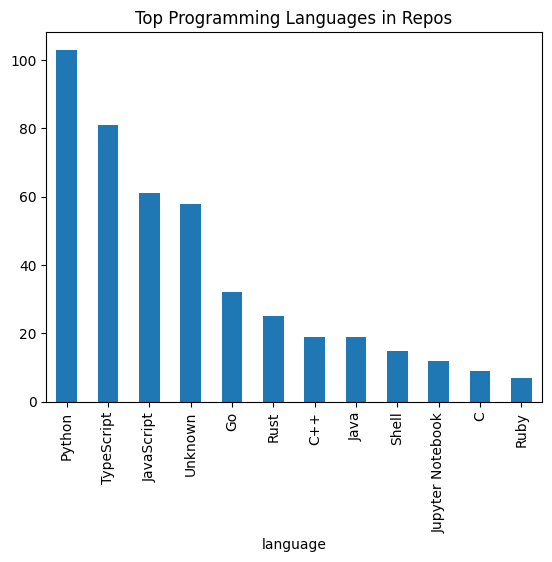

In [ ]:
plt.figure()
df["language"].value_counts().head(12).plot(kind = "bar")
plt.title("Top Programming Languages in Repos")

The most used languages are Python, TypeScript and JavaScript.

## Stars vs Forks

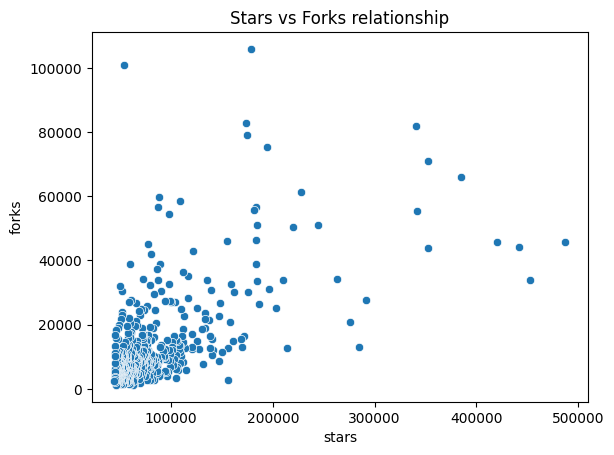

np.float64(0.6077665678896768)

In [ ]:
plt.figure()
sns.scatterplot(data = df, x = 'stars', y = 'forks')
plt.title("Stars vs Forks relationship")
plt.show()

df["stars"].corr(df["forks"])

They are moderately correlated, as shown in graph and correlation coefficient

## Stars vs Size relationship

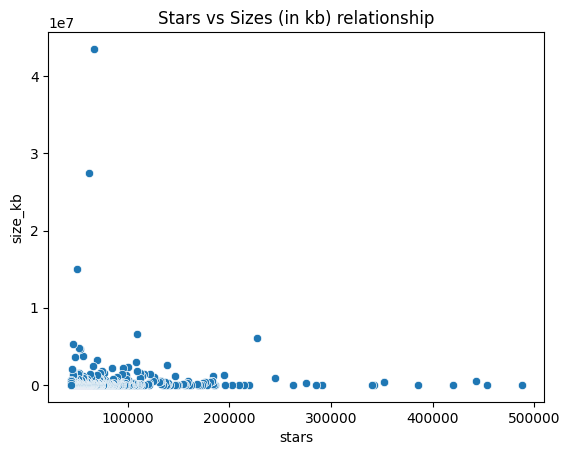

np.float64(-0.0115237642306266)

In [ ]:
plt.figure()
sns.scatterplot(data = df, x = 'stars', y = 'size_kb')
plt.title("Stars vs Sizes (in kb) relationship")
plt.show()

df["stars"].corr(df["size_kb"])

They are not realted (negatively correlated) as shown in graph and correlation coefficient

## Top 10 percent repositories

In [ ]:
threshold = df["stars"].quantile(0.9)

top_repos = df[df["stars"] >= threshold]
other_repos = df[df["stars"] < threshold]

In [ ]:
print("Threshold:", threshold)
print("Top repos:", len(top_repos))
print("Other repos:", len(other_repos))

Threshold: 138631.80000000002
Top repos: 50
Other repos: 450


Star counts exceeding 90th percentile

In [ ]:
comparison = pd.DataFrame({
    "Top 10%": [
        top_repos["stars"].mean(),
        top_repos["forks"].mean(),
        top_repos["size_kb"].mean()
    ],
    "Remaining 90%": [
        other_repos["stars"].mean(),
        other_repos["forks"].mean(),
        other_repos["size_kb"].mean()
    ]
}, index=["Stars", "Forks", "Size (KB)"])

print(comparison)

             Top 10%  Remaining 90%
Stars      223064.54   67915.702222
Forks       37490.80   10852.040000
Size (KB)  373833.02  482933.722222


In [ ]:
top_repos["language"].value_counts()

language
Python              12
Unknown             10
TypeScript           7
JavaScript           5
HTML                 3
Shell                2
Go                   2
Markdown             1
C                    1
C++                  1
Jupyter Notebook     1
Rust                 1
Dart                 1
MDX                  1
Batchfile            1
Java                 1
Name: count, dtype: int64

Unknown language, result will be dropped in final interpreation as metadata does not exist

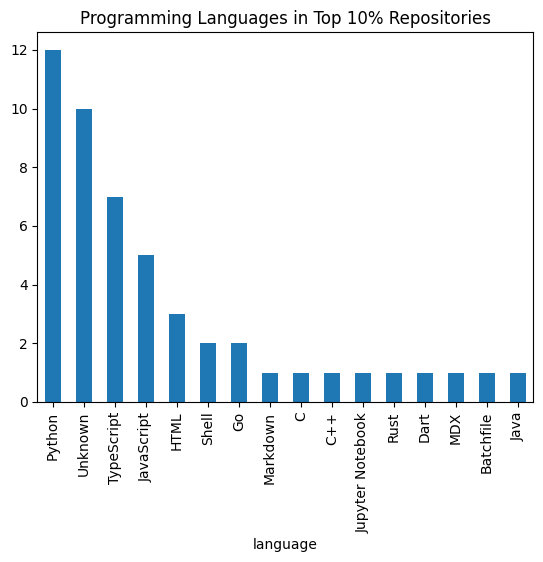

In [ ]:
top_repos["language"].value_counts().plot(kind="bar")
plt.title("Programming Languages in Top 10% Repositories")
plt.show()

Here we also see popularity of Python, TypeScript and JavaScript, but that does not mean they play crucial role here, in all repositories they also were highly used.

In [ ]:
top_repos["forks"].describe()

count        50.000000
mean      37490.800000
std       23135.574818
min        2664.000000
25%       17539.500000
50%       33201.500000
75%       50764.000000
max      105876.000000
Name: forks, dtype: float64

In [ ]:
other_repos["forks"].describe()

count       450.000000
mean      10852.040000
std        9804.702878
min        1237.000000
25%        5174.750000
50%        8277.500000
75%       12778.500000
max      100849.000000
Name: forks, dtype: float64